# RFM-I: Intent-Aware Customer Segmentation for Coupon Targeting

A. Setup  
B. Data  
C. Engineer featuring (variable)  
D. EDA  
E. Model  
F. Analysis  
G. AB testing

---
A. Setup

In [1]:
# I. Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# II. File path setting

import os

# Relative paths so the notebook runs anywhere the repo is cloned
input_path = 'data/data.csv'
output_dir = 'output'

os.makedirs(output_dir, exist_ok=True)

---
B. Data

In [11]:
# III. Data preview

def load_and_preprocess(filepath):
    """Load and preprocess data"""
    df = pd.read_csv(filepath)
    
    # Data quality check
    print("=" * 60)
    print("Phase 1: Data Quality Check")
    print("=" * 60)
    print(f"Data size: {df.shape[0]} rows x {df.shape[1]} columns")
    print(f"Missing values: {df.isnull().sum().sum()}")
    
    # Outlier detection
    age_outliers = df[(df['Age'] < 10) | (df['Age'] > 100)].shape[0]
    print(f"Age outliers: {age_outliers}")
    return df


# Execute data loading and preprocessing
df = load_and_preprocess(input_path)
df.head()

Phase 1: Data Quality Check
Data size: 1000 rows x 15 columns
Missing values: 0
Age outliers: 0


,Unnamed: 0,User_ID,Age,Gender,Location,Income,Interests,Last_Login_Days_Ago,Purchase_Frequency,Average_Order_Value,Total_Spending,Product_Category_Preference,Time_Spent_on_Site_Minutes,Pages_Viewed,Newsletter_Subscription
0,0,#1,56,Male,Suburban,38037,Sports,5,7,18,2546,Books,584,38,True
1,1,#2,46,Female,Rural,103986,Technology,15,7,118,320,Electronics,432,40,False
2,2,#3,32,Female,Suburban,101942,Sports,28,1,146,3766,Apparel,306,1,True
3,3,#4,60,Female,Suburban,71612,Fashion,18,3,163,4377,Apparel,527,29,False
4,4,#5,25,Male,Suburban,49725,Travel,2,5,141,4502,Health & Beauty,53,10,True


---
C. Feature Engineering

In [13]:
# IV. Feature Engineering

def feature_engineering(df):
    """Feature Engineering: Build all metrics required for the RFM-I model"""
    
    print("\n" + "=" * 60)
    print("Phase 2: Feature Engineering - Building Optimization Metrics")
    print("=" * 60)
    
    # 1. Basic RFM metrics are already in the data
    
    
    # 2. I (Intent - Depth of Intent)
    def min_max_normalize(series, reverse=False):
        min_val, max_val = series.min(), series.max()
        if max_val == min_val:
            return pd.Series([50] * len(series))
        if reverse:
            return ((max_val - series) / (max_val - min_val)) * 100
            #### lower is better (needs specify reverse=True)
        return ((series - min_val) / (max_val - min_val)) * 100
        #### higher is better (default reverse=False)
    
    df['Time_Spent_Norm'] = min_max_normalize(df['Time_Spent_on_Site_Minutes'])
    df['Pages_Viewed_Norm'] = min_max_normalize(df['Pages_Viewed'])
    df['I_Score'] = 0.5 * df['Time_Spent_Norm'] + 0.5 * df['Pages_Viewed_Norm']
    df['Friction'] = df['Pages_Viewed'] / (df['Purchase_Frequency'] + 1)
    
    
    # 3. L (Loyalty - Active Connection Level)
    def calculate_loyalty(row):
        subscribed = row['Newsletter_Subscription']
        login_days = row['Last_Login_Days_Ago']
        if subscribed and login_days < 7:
            return 3
        elif not subscribed and login_days < 7:
            return 2
        else:
            return 1
    df['L_Score'] = df.apply(calculate_loyalty, axis=1)
    
    
    # 4. D (Demographics - Purchasing Power Background)
    income_33 = df['Income'].quantile(0.33)
    income_66 = df['Income'].quantile(0.66)
    def income_level(income):
        if income <= income_33:
            return 'Low'
        elif income <= income_66:
            return 'Medium'
        else:
            return 'High'
    df['Income_Level'] = df['Income'].apply(income_level)
    
    
    # 5. Person-Product Match Degree
    df['Interest_Match'] = (df['Interests'] == df['Product_Category_Preference']).astype(int)
    
    print(f"I_Score range: [{df['I_Score'].min():.2f}, {df['I_Score'].max():.2f}]")
    print(f"Friction range: [{df['Friction'].min():.2f}, {df['Friction'].max():.2f}]")
    print(f"L_Score distribution: {df['L_Score'].value_counts().to_dict()}")
    print(f"Income_Level distribution: {df['Income_Level'].value_counts().to_dict()}")
    print(f"Interest_Match match rate: {df['Interest_Match'].mean()*100:.1f}%")
    
    return df



    
df = feature_engineering(df)
df[['User_ID','I_Score','Friction','L_Score','Income_Level','Interest_Match']].head()


Phase 2: Feature Engineering - Building Optimization Metrics
I_Score range: [0.00, 98.83]
Friction range: [0.10, 49.00]
L_Score distribution: {1: 824, 3: 99, 2: 77}
Income_Level distribution: {'High': 340, 'Low': 330, 'Medium': 330}
Interest_Match match rate: 0.0%


,User_ID,I_Score,Friction,L_Score,Income_Level,Interest_Match
0,#1,87.285385,4.750000,3,Low,0
1,#2,76.638400,5.000000,1,High,0
2,#3,25.460637,0.500000,1,High,0
3,#4,73.136516,7.250000,1,Medium,0
4,#5,13.646357,1.666667,3,Low,0


<br>

---
D. EDA


Phase 3: EDA Exploratory Data Analysis


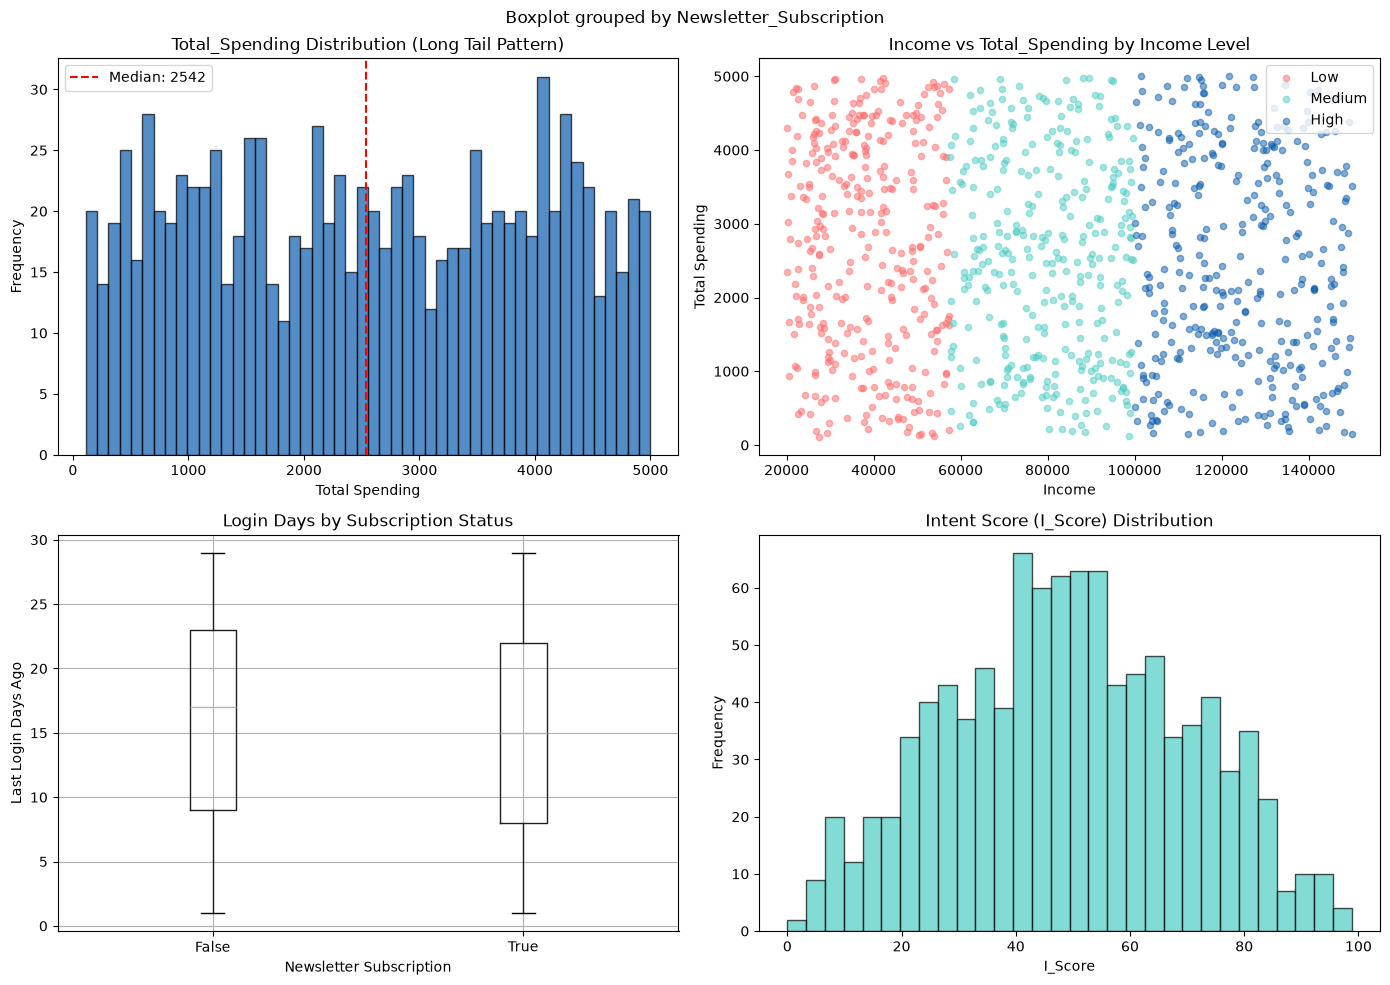

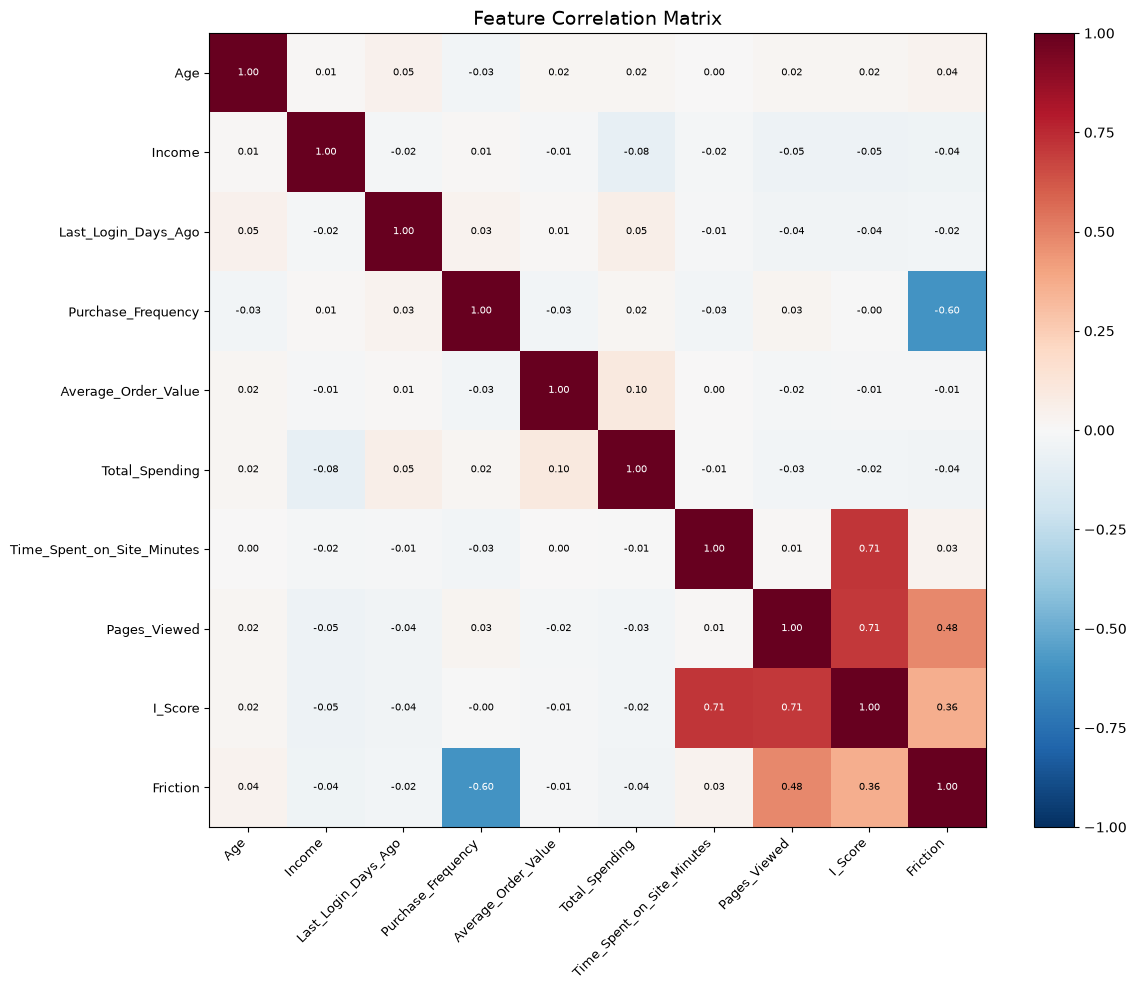


Key Correlation Analysis:
Time_Spent vs Purchase_Frequency correlation coefficient: -0.028
Pages_Viewed vs Purchase_Frequency correlation coefficient: 0.026

High Friction Users (Top 25%) Characteristics:
  - Average pages viewed: 34.3
  - Average purchase frequency: 1.6
  - Average spending amount: 2514

High Income, Low Spending Group:
  - Number of users: 184
  - Proportion of high income group: 54.1%


In [14]:
# V. EDA Exploratory Data Analysis

def perform_eda(df, output_dir):
    """EDA Analysis: distributions, correlations, behavioral insights"""
    
    print("\n" + "=" * 60)
    print("Phase 3: EDA Exploratory Data Analysis")
    print("=" * 60)
    
    # 1. Key distribution analysis
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    #1.1 Total_Spending distribution
    axes[0, 0].hist(df['Total_Spending'], bins=50, edgecolor='black', alpha=0.7, color='#0B5CAD')
    axes[0, 0].set_title('Total_Spending Distribution (Long Tail Pattern)', fontsize=12)
    axes[0, 0].set_xlabel('Total Spending')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].axvline(df['Total_Spending'].median(), color='red', linestyle='--', 
                       label=f'Median: {df["Total_Spending"].median():.0f}')
    axes[0, 0].legend()
    
    #1.2 Income vs Total_Spending scatter plot
    colors = {'Low': '#FF6B6B', 'Medium': '#4ECDC4', 'High': '#0B5CAD'}
    for level in ['Low', 'Medium', 'High']:
        subset = df[df['Income_Level'] == level]
        axes[0, 1].scatter(subset['Income'], subset['Total_Spending'], 
                          alpha=0.5, label=level, c=colors[level], s=20)
    axes[0, 1].set_title('Income vs Total_Spending by Income Level', fontsize=12)
    axes[0, 1].set_xlabel('Income')
    axes[0, 1].set_ylabel('Total Spending')
    axes[0, 1].legend()
    
    #1.3 Last_Login_Days_Ago vs Newsletter_Subscription box plot
    df.boxplot(column='Last_Login_Days_Ago', by='Newsletter_Subscription', ax=axes[1, 0])
    axes[1, 0].set_title('Login Days by Subscription Status', fontsize=12)
    axes[1, 0].set_xlabel('Newsletter Subscription')
    axes[1, 0].set_ylabel('Last Login Days Ago')
    
    #1.4 I_Score distribution
    axes[1, 1].hist(df['I_Score'], bins=30, edgecolor='black', alpha=0.7, color='#4ECDC4')
    axes[1, 1].set_title('Intent Score (I_Score) Distribution', fontsize=12)
    axes[1, 1].set_xlabel('I_Score')
    axes[1, 1].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/eda_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    
    
    # 2. Correlation analysis
    numeric_cols = ['Age', 'Income', 'Last_Login_Days_Ago', 'Purchase_Frequency', 
                    'Average_Order_Value', 'Total_Spending', 'Time_Spent_on_Site_Minutes', 
                    'Pages_Viewed', 'I_Score', 'Friction']
    
    corr_matrix = df[numeric_cols].corr()
    
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(corr_matrix, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
    ax.set_xticks(range(len(numeric_cols)))
    ax.set_yticks(range(len(numeric_cols)))
    ax.set_xticklabels(numeric_cols, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(numeric_cols, fontsize=9)
    
    for i in range(len(numeric_cols)):
        for j in range(len(numeric_cols)):
            text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                          ha='center', va='center', fontsize=7,
                          color='white' if abs(corr_matrix.iloc[i, j]) > 0.5 else 'black')
    
    ax.set_title('Feature Correlation Matrix', fontsize=14)
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/correlation_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    
    # 3. Key behavioral insights
    time_purchase_corr = df['Time_Spent_on_Site_Minutes'].corr(df['Purchase_Frequency'])
    pages_purchase_corr = df['Pages_Viewed'].corr(df['Purchase_Frequency'])
    
    print(f"\nKey Correlation Analysis:")
    print(f"Time_Spent vs Purchase_Frequency correlation coefficient: {time_purchase_corr:.3f}")
    print(f"Pages_Viewed vs Purchase_Frequency correlation coefficient: {pages_purchase_corr:.3f}")
    
    # High friction user analysis
    high_friction = df[df['Friction'] > df['Friction'].quantile(0.75)]
    print(f"\nHigh Friction Users (Top 25%) Characteristics:")
    print(f"  - Average pages viewed: {high_friction['Pages_Viewed'].mean():.1f}")
    print(f"  - Average purchase frequency: {high_friction['Purchase_Frequency'].mean():.1f}")
    print(f"  - Average spending amount: {high_friction['Total_Spending'].mean():.0f}")
    
    # High income, low spending group
    high_income_low_spend = df[(df['Income_Level'] == 'High') & 
                               (df['Total_Spending'] < df['Total_Spending'].median())]
    print(f"\nHigh Income, Low Spending Group:")
    print(f"  - Number of users: {len(high_income_low_spend)}")
    print(f"  - Proportion of high income group: {len(high_income_low_spend)/len(df[df['Income_Level']=='High'])*100:.1f}%")
    
    return {
        'time_purchase_corr': time_purchase_corr,
        'pages_purchase_corr': pages_purchase_corr,
        'high_friction_count': len(high_friction),
        'high_income_low_spend_count': len(high_income_low_spend)
    }




eda_results = perform_eda(df, output_dir)

<br>

---
E. Model construction

In [7]:
# VI. RFM-I Model Construction

def build_rfm_model(df):
    """Build the RFM-I model: normalization, composite score calculation"""
    
    print("\n" + "=" * 60)
    print("Phase 4: RFM-I Model Construction")
    print("=" * 60)
    
    # Normalization function
    def min_max_normalize(series, reverse=False):
        min_val, max_val = series.min(), series.max()
        if max_val == min_val:
            return pd.Series([50] * len(series))
        if reverse:
            return ((max_val - series) / (max_val - min_val)) * 100
        return ((series - min_val) / (max_val - min_val)) * 100
    
    df['R_Score'] = min_max_normalize(df['Last_Login_Days_Ago'], reverse=True)
    df['F_Score'] = min_max_normalize(df['Purchase_Frequency'])
    df['M_Score'] = min_max_normalize(df['Total_Spending'])
    df['RFM_Score'] = 0.2 * df['R_Score'] + 0.3 * df['F_Score'] + 0.5 * df['M_Score']
    df['I_Weight'] = df['I_Score'] / 500  # I_Score 0-100 -> 0-0.2
    df['Final_Score'] = df['RFM_Score'] * (1 + df['I_Weight'])
    
    print(f"R_Score range: [{df['R_Score'].min():.2f}, {df['R_Score'].max():.2f}]")
    print(f"F_Score range: [{df['F_Score'].min():.2f}, {df['F_Score'].max():.2f}]")
    print(f"M_Score range: [{df['M_Score'].min():.2f}, {df['M_Score'].max():.2f}]")
    print(f"RFM_Score range: [{df['RFM_Score'].min():.2f}, {df['RFM_Score'].max():.2f}]")
    print(f"Final_Score range: [{df['Final_Score'].min():.2f}, {df['Final_Score'].max():.2f}]")
    
    return df


    
df = build_rfm_model(df)
df[['User_ID','R_Score','F_Score','M_Score','I_Score','RFM_Score','Final_Score']].head()


Phase 4: RFM-I Model Construction
R_Score range: [0.00, 100.00]
F_Score range: [0.00, 100.00]
M_Score range: [0.00, 100.00]
RFM_Score range: [4.72, 96.77]
Final_Score range: [5.26, 105.06]


,User_ID,R_Score,F_Score,M_Score,I_Score,RFM_Score,Final_Score
0,#1,85.714286,77.777778,49.805607,87.285385,65.378994,76.792255
1,#2,50.000000,77.777778,4.256190,76.638400,35.461428,40.896843
2,#3,3.571429,11.111111,74.769797,25.460637,41.432518,43.542314
3,#4,39.285714,33.333333,87.272355,73.136516,61.493320,70.488135
4,#5,96.428571,55.555556,89.830162,13.646357,80.867462,83.074554


<br>

---
F. Result

In [8]:
# VII. User Segmentation and Profiling

def classify_users(df):
    """User Segmentation: fine-grained segmentation based on the RFM-I model"""
    
    print("\n" + "=" * 60)
    print("Phase 5: User Segmentation and Profiling")
    print("=" * 60)
    
    def classify_user(row):
        r = row['R_Score']
        f = row['F_Score']
        m = row['M_Score']
        i = row['I_Score']
        income = row['Income_Level']
        friction = row['Friction']
        l = row['L_Score']
        
        # Basic RFM segmentation logic
        if r > 60 and f > 60 and m > 60:
            base_label = "Important Value Users"
        elif r > 60 and m > 60 and f < 40:
            base_label = "Important Development Users"
        elif r < 40 and f > 60 and m > 60:
            base_label = "Important Retention Users"
        elif r < 40 and m > 60:
            base_label = "Important Win-back Users"
        elif r > 60 and f > 40 and m < 40:
            base_label = "General Development Users"
        elif r > 60 and f < 40 and m < 40:
            base_label = "General Maintenance Users"
        elif r < 40 and f < 40 and m < 40:
            base_label = "Low Value Users"
        else:
            base_label = "General Users"
        
        # Key correction logic
        if base_label in ["Low Value Users", "General Maintenance Users"] and income == "High" and i > 60:
            return "High-Potential Dormant Users"
        if income == "High" and i > 70 and f < 40 and m < 50:
            return "Hesitant Big Spenders"
        if base_label in ["General Maintenance Users", "General Development Users"] and i > 80 and friction > df['Friction'].quantile(0.6):
            return "Hesitant Potential Users"
        if income == "Low" and i > 70 and f < 40:
            return "Hidden Active Users"
        if income == "High" and r < 40 and m > 50:
            return "High-Potential Churn Customers"
        if m > 70 and f > 70 and i > 60:
            return "Core VIP"
        if income == "Low" and i < 40 and m < 40:
            return "Freebie Seekers/Low Value"
        
        return base_label
    
    df['User_Segment'] = df.apply(classify_user, axis=1)
    
    # Segment statistics
    segment_stats = df.groupby('User_Segment').agg({
        'User_ID': 'count',
        'Total_Spending': 'mean',
        'Purchase_Frequency': 'mean',
        'I_Score': 'mean',
        'Income': 'mean',
        'Final_Score': 'mean'
    }).round(2)
    
    segment_stats.columns = ['User Count', 'Average Spending', 'Average Purchase Frequency', 'Average Intent Score', 'Average Income', 'Average Final Score']
    segment_stats['Percentage(%)'] = (segment_stats['User Count'] / len(df) * 100).round(1)
    segment_stats = segment_stats.sort_values('User Count', ascending=False)
    
    print("\nUser Segmentation Statistics:")
    print(segment_stats.to_string())
    
    return df, segment_stats


    
df, segment_stats = classify_users(df)


Phase 5: User Segmentation and Profiling

User Segmentation Statistics:
                                User Count  Average Spending  Average Purchase Frequency  Average Intent Score  Average Income  Average Final Score  Percentage(%)
User_Segment                                                                                                                                                      
General Users                          443           2368.12                        5.17                 48.80        84305.72                54.31           44.3
General Development Users               81           1117.95                        6.43                 49.84        87107.43                52.67            8.1
Important Win-back Users                67           4134.42                        2.57                 46.53        59698.61                58.59            6.7
High-Potential Churn Customers          64           3990.70                        4.92                 44.09  

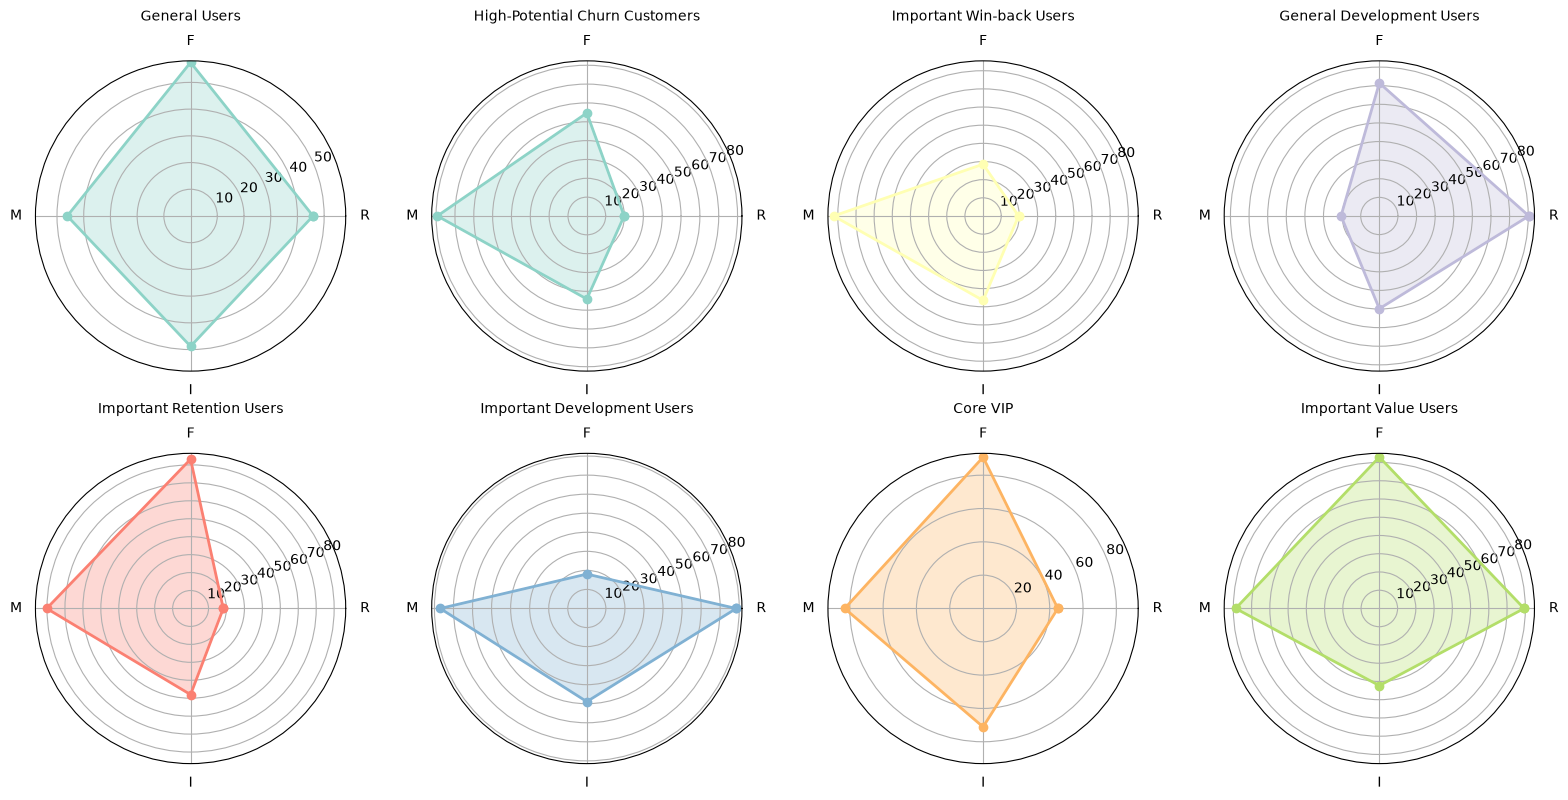

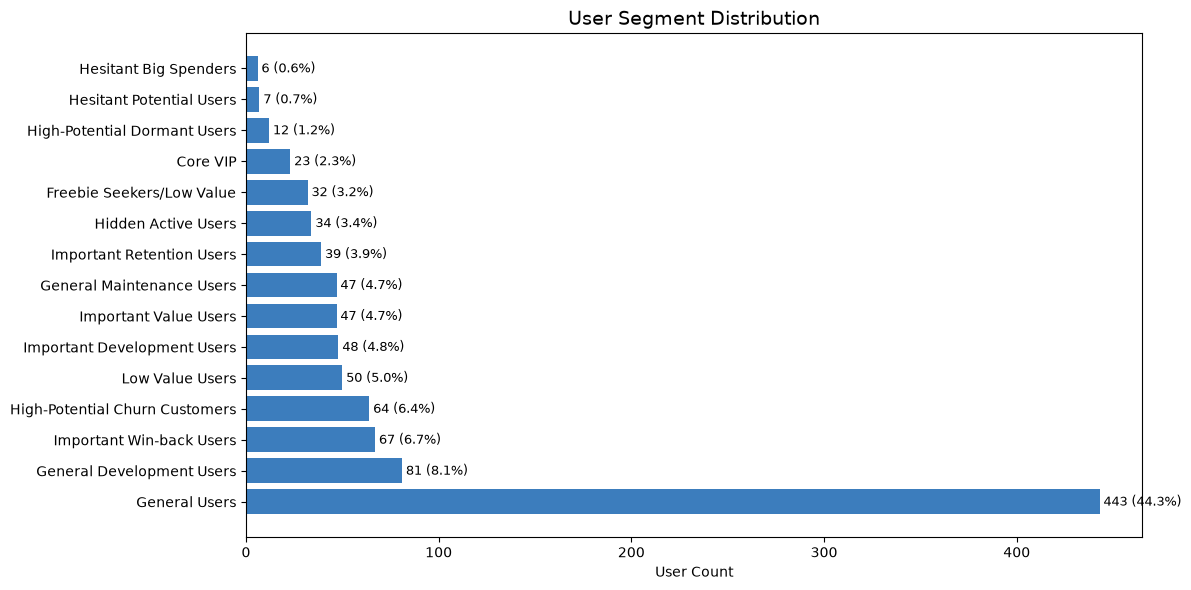

In [9]:
# VIII. Generate User Portrait Visualizations

def generate_segment_portrait(df, output_dir):
    """Generate user portrait visualizations: radar charts and distribution bar chart"""
    
    #1. Segment radar charts
    segments = df['User_Segment'].unique()
    metrics = ['R_Score', 'F_Score', 'M_Score', 'I_Score']
    
    segment_means = df.groupby('User_Segment')[metrics].mean()
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8), subplot_kw=dict(polar=True))
    axes = axes.flatten()
    
    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]
    
    colors = plt.cm.Set3(np.linspace(0, 1, len(segments)))
    
    for idx, segment in enumerate(segments[:8]):
        if idx >= len(axes):
            break
        ax = axes[idx]
        values = segment_means.loc[segment].tolist()
        values += values[:1]
        
        ax.fill(angles, values, alpha=0.3, color=colors[idx])
        ax.plot(angles, values, 'o-', color=colors[idx], linewidth=2)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(['R', 'F', 'M', 'I'], fontsize=10)
        ax.set_title(segment, fontsize=10, pad=10)
    
    for idx in range(len(segments), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/segment_radar.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    
    #2. Segment distribution bar chart
    segment_counts = df['User_Segment'].value_counts()
    
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.barh(segment_counts.index, segment_counts.values, color='#0B5CAD', alpha=0.8)
    ax.set_xlabel('User Count')
    ax.set_title('User Segment Distribution', fontsize=14)
    
    for bar, count in zip(bars, segment_counts.values):
        ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2, 
                f'{count} ({count/len(df)*100:.1f}%)', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/segment_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
generate_segment_portrait(df, output_dir)

<br>

---
G. AB testing


Phase 6: ROI Calculation

[Assumed Parameters]
  Total budget: 10000 yuan
  Coupon cost: 10 yuan/person
  Average order value: 104 yuan

[Conversion Rate Assumptions]
  RFM top 20% users: natural conversion rate 20.0%, after coupon 30.0%, marginal lift 10.0%
  Core users: natural conversion rate 25.0%, after coupon 30.0%, marginal lift 5.0%
  Potential users: natural conversion rate 1.0%, after coupon 20.0%, marginal lift 19.0%

[Strategy A - Traditional RFM Strategy]
  Target user count: 200
  Cost: 2000 yuan
  Marginal revenue (incremental): 2081 yuan
  Marginal ROI: 4.0%

[Strategy B - Optimized RFI Strategy]
  Core users: 70
  Newly discovered potential users: 89
  Total target user count: 159
  Actual cost: 1590 yuan (budget utilization: 15.9%)
  Marginal revenue (incremental): 2123 yuan
  Marginal ROI: 33.5%


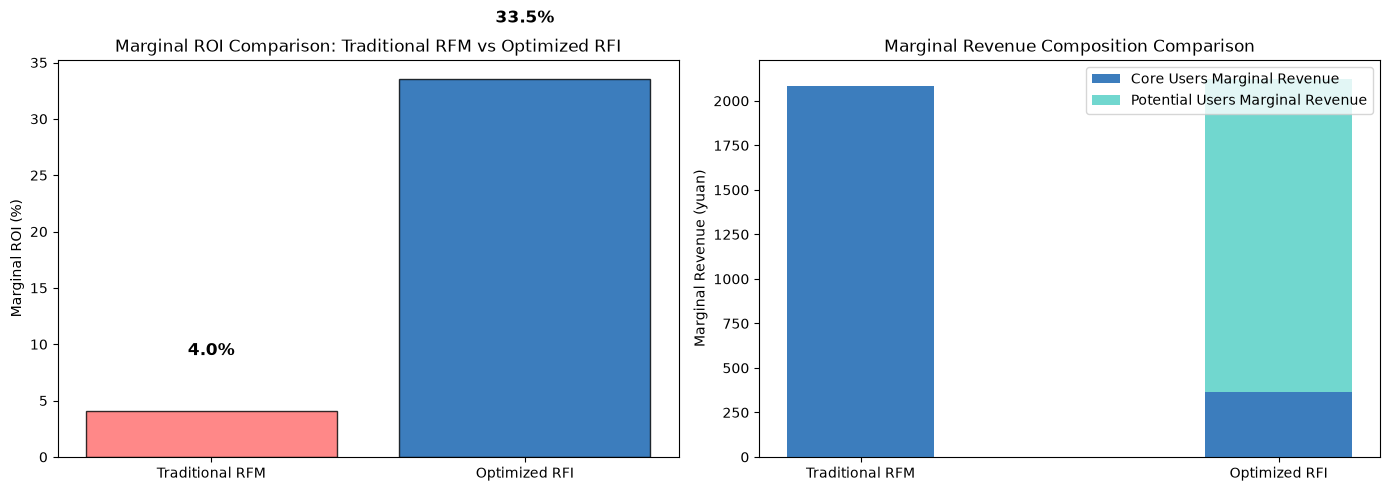

In [10]:
# IX. ROI Calculation

def calculate_roi(df, output_dir):
    """ROI Calculation: Traditional RFM vs Optimized RFI Strategy Comparison (Marginal Revenue Method, Adjustable Parameters)"""
    
    print("\n" + "=" * 60)
    print("Phase 6: ROI Calculation")
    print("=" * 60)
    
    # ================= Adjustable Parameters =================
    total_budget = 10000          # Total budget (yuan)
    coupon_cost = 10               # Cost per coupon (yuan)
    aov = df['Average_Order_Value'].mean()  # Average order value (yuan)
    
    # Conversion rate assumptions (can be calibrated based on historical data)
    # Core users
    core_natural = 0.25            # Core users' natural conversion rate without coupon
    core_with_coupon = 0.30        # Core users' conversion rate after receiving coupon
    # Potential users
    potential_natural = 0.01       # Potential users' natural conversion rate
    potential_with_coupon = 0.20   # Potential users' conversion rate after receiving coupon (can be adjusted up to 20%-25%)
    # General users (used as baseline for Strategy A)
    general_natural = 0.02          # General users' natural conversion rate
    # Natural conversion rate for RFM top 20% users (between core and general)
    rfm20_natural = 0.20            # Can be adjusted based on actual data, e.g., RFM high-score users typically have higher conversion rates
    rfm20_with_coupon = 0.30        # Conversion rate after receiving coupon (typically won't exceed core users)
    
    # Marginal lift
    core_lift = core_with_coupon - core_natural
    potential_lift = potential_with_coupon - potential_natural
    rfm20_lift = rfm20_with_coupon - rfm20_natural
    
    # ================= Strategy A: Traditional RFM Strategy =================
    top20_threshold = df['RFM_Score'].quantile(0.80)
    rfm_top20 = df[df['RFM_Score'] >= top20_threshold]
    target_a_count = min(len(rfm_top20), total_budget // coupon_cost)
    cost_a = target_a_count * coupon_cost
    
    incremental_revenue_a = target_a_count * rfm20_lift * aov
    roi_a = (incremental_revenue_a - cost_a) / cost_a * 100 if cost_a > 0 else 0
    
    # ================= Strategy B: Optimized RFI Strategy =================
    core_users = df[df['User_Segment'].isin(['Core VIP', 'Important Value Users'])]
    potential_users = df[df['User_Segment'].isin(['Hesitant Big Spenders', 'High-Potential Dormant Users', 'Hesitant Potential Users', 'High-Potential Churn Customers'])]
    
    # Allocate budget: prioritize core users (using 80% of budget), remainder to potential users
    core_count = min(len(core_users), int(total_budget * 0.8 / coupon_cost))
    remaining_budget = total_budget - core_count * coupon_cost
    potential_count = min(len(potential_users), remaining_budget // coupon_cost)
    target_b_count = core_count + potential_count
    cost_b = target_b_count * coupon_cost
    
    incremental_revenue_b = core_count * core_lift * aov + potential_count * potential_lift * aov
    roi_b = (incremental_revenue_b - cost_b) / cost_b * 100 if cost_b > 0 else 0
    
    # ================= Output Results =================
    print(f"\n[Assumed Parameters]")
    print(f"  Total budget: {total_budget} yuan")
    print(f"  Coupon cost: {coupon_cost} yuan/person")
    print(f"  Average order value: {aov:.0f} yuan")
    
    print(f"\n[Conversion Rate Assumptions]")
    print(f"  RFM top 20% users: natural conversion rate {rfm20_natural*100:.1f}%, after coupon {rfm20_with_coupon*100:.1f}%, marginal lift {rfm20_lift*100:.1f}%")
    print(f"  Core users: natural conversion rate {core_natural*100:.1f}%, after coupon {core_with_coupon*100:.1f}%, marginal lift {core_lift*100:.1f}%")
    print(f"  Potential users: natural conversion rate {potential_natural*100:.1f}%, after coupon {potential_with_coupon*100:.1f}%, marginal lift {potential_lift*100:.1f}%")
    
    print(f"\n[Strategy A - Traditional RFM Strategy]")
    print(f"  Target user count: {target_a_count}")
    print(f"  Cost: {cost_a} yuan")
    print(f"  Marginal revenue (incremental): {incremental_revenue_a:.0f} yuan")
    print(f"  Marginal ROI: {roi_a:.1f}%")
    
    print(f"\n[Strategy B - Optimized RFI Strategy]")
    print(f"  Core users: {core_count}")
    print(f"  Newly discovered potential users: {potential_count}")
    print(f"  Total target user count: {target_b_count}")
    print(f"  Actual cost: {cost_b} yuan (budget utilization: {cost_b/total_budget*100:.1f}%)")
    print(f"  Marginal revenue (incremental): {incremental_revenue_b:.0f} yuan")
    print(f"  Marginal ROI: {roi_b:.1f}%")
    
    # ROI comparison visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Marginal ROI comparison
    strategies = ['Traditional RFM', 'Optimized RFI']
    rois = [roi_a, roi_b]
    colors = ['#FF6B6B', '#0B5CAD']
    
    bars = axes[0].bar(strategies, rois, color=colors, alpha=0.8, edgecolor='black')
    axes[0].set_ylabel('Marginal ROI (%)')
    axes[0].set_title('Marginal ROI Comparison: Traditional RFM vs Optimized RFI', fontsize=12)
    for bar, roi in zip(bars, rois):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                    f'{roi:.1f}%', ha='center', fontsize=12, fontweight='bold')
    
    # Marginal revenue composition comparison
    x = np.arange(2)
    width = 0.35
    
    core_marginal = [incremental_revenue_a, core_count * core_lift * aov]
    potential_marginal = [0, potential_count * potential_lift * aov]
    
    axes[1].bar(x, core_marginal, width, label='Core Users Marginal Revenue', color='#0B5CAD', alpha=0.8)
    axes[1].bar(x, potential_marginal, width, bottom=core_marginal, label='Potential Users Marginal Revenue', color='#4ECDC4', alpha=0.8)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(strategies)
    axes[1].set_ylabel('Marginal Revenue (yuan)')
    axes[1].set_title('Marginal Revenue Composition Comparison', fontsize=12)
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/roi_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    
    return {
        'strategy_a': {
            'target_count': int(target_a_count),
            'cost': cost_a,
            'incremental_revenue': incremental_revenue_a,
            'marginal_roi': roi_a
        },
        'strategy_b': {
            'core_count': int(core_count),
            'potential_count': int(potential_count),
            'total_count': int(target_b_count),
            'actual_cost': cost_b,
            'budget_used_ratio': cost_b/total_budget,
            'incremental_revenue': incremental_revenue_b,
            'marginal_roi': roi_b
        },
        'params': {
            'budget': total_budget,
            'coupon_cost': coupon_cost,
            'aov': aov,
            'rfm20_lift': rfm20_lift,
            'core_lift': core_lift,
            'potential_lift': potential_lift
        }
    }
roi_results = calculate_roi(df, output_dir)